# connectivints  basline (no flood)
没有flood的时候，都是这样做的；

## 1. Network Baseline: Identifying Critical Infrastructure

### Methodology: Why Graph Theory?
To understand the systemic vulnerability of Hat Yai, we cannot look at roads in isolation. We must analyze the **topological structure** of the entire transportation network.

We utilize **Network Science (Graph Theory)** to identify critical intersections that act as "bridges" or "bottlenecks" within the city. The primary metric used in this analysis is **Betweenness Centrality**.

### Metric: Betweenness Centrality
Betweenness Centrality ($C_B$) measures the influence of a node over the flow of the network. It is defined as the fraction of all shortest paths between node pairs that pass through the specific node of interest.

> **In simple terms:** If everyone in the city tries to take the shortest route to their destination, which intersections will be the most crowded?

* **High Centrality (Bright Colors):** These are the city's **"Arteries"**. If these nodes are inundated, the network becomes fragmented, forcing massive detours.
* **Low Centrality (Dark Colors):** These are peripheral roads with high redundancy.

### Data Source
* **Network:** Driveable street network derived from **OpenStreetMap (OSM)** via the `OSMnx` library.
* **Weighting:** Calculations are based on **physical distance**, assuming emergency logistics prioritize the shortest path.

🚀 正在构建路网拓扑 (Baseline)...
⏳ 正在计算中心性指标 (可能需要 1-2 分钟，请耐心等待)...
🎨 正在绘制网络结构热力图...


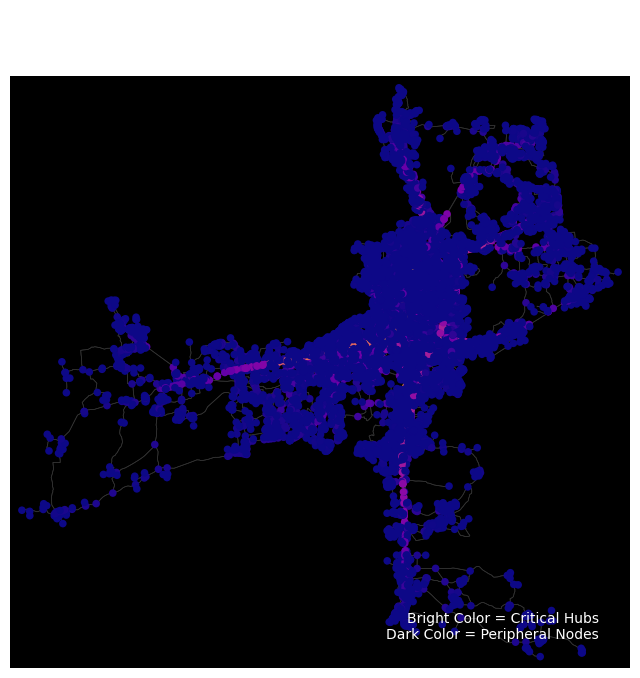

In [2]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import geopandas as gpd

# ==========================================
# 1. 准备数据 & 构建拓扑
# ==========================================
print("🚀 正在构建路网拓扑 (Baseline)...")

# 下载合艾路网 (Drive Network)
# 这一步建立图结构 (Nodes & Edges)
place_name = "Hat Yai, Songkhla, Thailand"
G = ox.graph_from_place(place_name, network_type='drive')

# 投影到 UTM (米单位)，这对于计算中心性和距离非常重要！
G_proj = ox.project_graph(G)

# ==========================================
# 2. 计算介数中心性 (Betweenness Centrality)
# ==========================================
print("⏳ 正在计算中心性指标 (可能需要 1-2 分钟，请耐心等待)...")

# 计算由图构成的 DiGraph 的中心性
# weight='length' 表示我们假设人们倾向于走最短的路
bc = nx.betweenness_centrality(ox.get_digraph(G_proj), weight='length')

# 把计算结果写入节点属性
nx.set_node_attributes(G_proj, bc, 'bc')

# ==========================================
# 3. 可视化：热力图
# ==========================================
print("🎨 正在绘制网络结构热力图...")

# 根据中心性数值给节点上色 (Plasma 色系：紫色低 -> 黄色高)
nc = ox.plot.get_node_colors_by_attr(G_proj, 'bc', cmap='plasma')

fig, ax = ox.plot_graph(
    G_proj,
    node_color=nc,
    node_size=30,       # 节点大小
    node_zorder=2,      # 节点在路网之上
    edge_color='#333333', # 深灰背景路网
    edge_linewidth=0.5,
    bgcolor='black',    # 黑色底图显专业
    show=False,
    close=False
)

ax.set_title("Baseline Network Topology: Critical Nodes\n(Metric: Betweenness Centrality)", 
             color='white', fontsize=15, pad=20)

# 加个简单的解释
ax.text(0.95, 0.05, "Bright Color = Critical Hubs\nDark Color = Peripheral Nodes", 
        transform=ax.transAxes, ha='right', color='white', fontsize=10)

plt.show()

🎨 正在进行美化绘图...


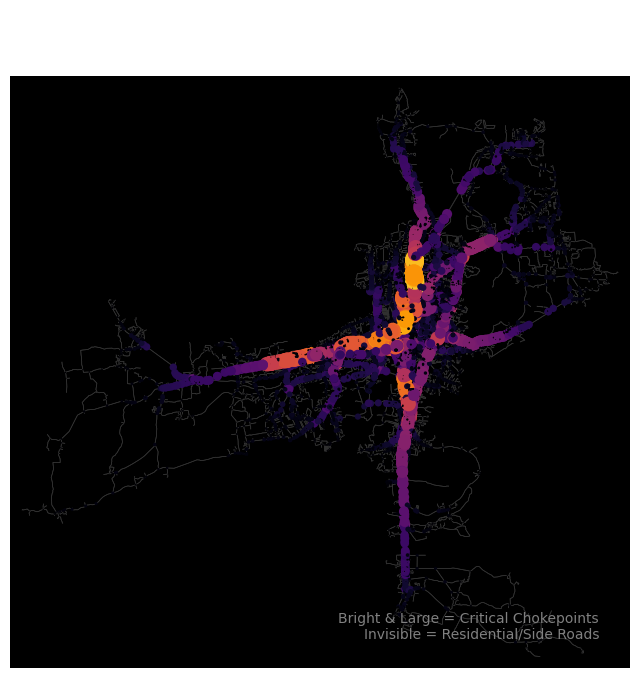

In [3]:
import matplotlib.pyplot as plt
import osmnx as ox
import networkx as nx

# 确保 G_proj 和 bc 还在内存里
# 如果没有，请先运行上一段计算 bc 的代码

print("🎨 正在进行美化绘图...")

# ==========================================
# 秘诀 1: 动态设置节点大小
# ==========================================
# 重要的点画大一点，不重要的点直接隐身 (size=0)
# 我们把中心性数值放大 1000 倍作为尺寸
node_sizes = [bc[node] * 1500 for node in G_proj.nodes()]

# ==========================================
# 秘诀 2: 使用高对比度颜色
# ==========================================
# 使用 'inferno' (黑-火红-黄) 配色，比 plasma 对比度更高
nc = ox.plot.get_node_colors_by_attr(G_proj, 'bc', cmap='inferno')

# ==========================================
# 3. 绘图 (赛博朋克风)
# ==========================================
fig, ax = ox.plot_graph(
    G_proj,
    node_color=nc,
    node_size=node_sizes,  # <--- 关键！大小随重要性变化
    node_zorder=2,
    edge_color='#333333',  # 路网弄成深灰，做背景
    edge_linewidth=0.5,    # 线细一点，精致
    bgcolor='black',       # 黑底
    show=False,
    close=False
)

ax.set_title("Network Topology: Critical Hubs\n(Size/Color = Betweenness Centrality)", 
             color='white', fontsize=15, pad=20)

# 加个注释帮读者看图
ax.text(0.95, 0.05, "Bright & Large = Critical Chokepoints\nInvisible = Residential/Side Roads", 
        transform=ax.transAxes, ha='right', color='gray', fontsize=10)

plt.show()

🔄 正在重新加载洪水数据...
✅ 数据加载修复完成！
🌊 正在模拟路网切断...
⚠️ 共有 4503 个节点被洪水物理切断。
🎨 正在绘制破坏图...


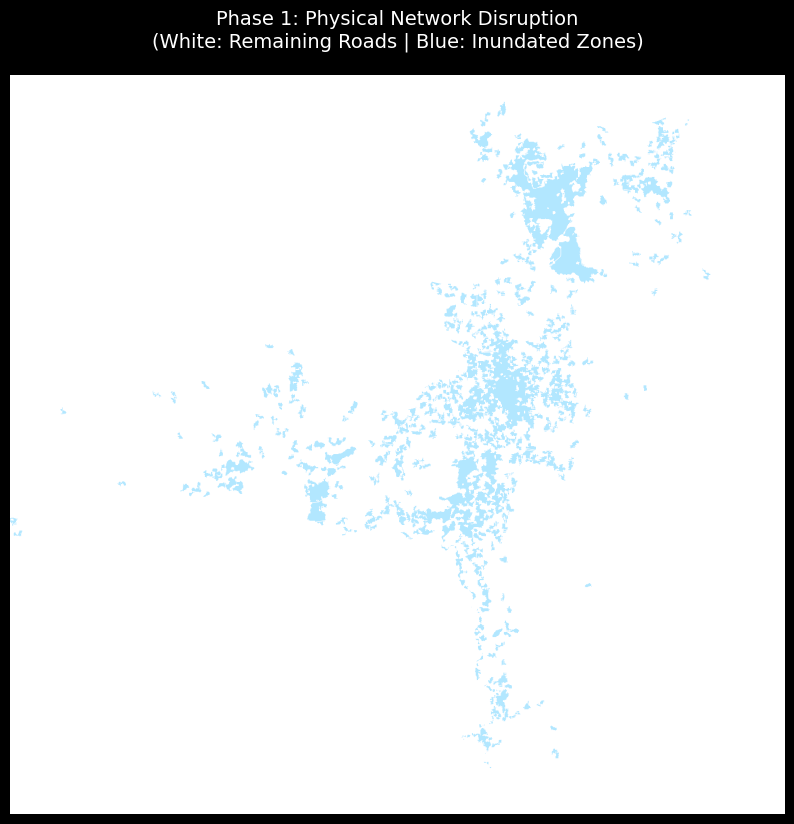

In [5]:
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt

# ==========================================
# 1. 补救步骤：重新加载缺失的数据
# ==========================================
print("🔄 正在重新加载洪水数据...")

# 洪水文件路径
flood_path = "data/EOS-RS_20251109_FPM_S1_Philippines_Bicol_Region_Typhoon_Fung-Wong_v0.9_shp/EOS-RS_20251123_FPM_S1_Thailand_Hat_Yai_Floods_v0.9_shp.shp"

# 1. 读取 Shapefile
try:
    flood_gdf = gpd.read_file(flood_path)
except Exception as e:
    print(f"❌ 找不到文件: {e}")

# 2. 确保 G_proj 存在 (路网)
if 'G_proj' not in globals():
    print("正在重新下载路网 (Baseline)...")
    place_name = "Hat Yai, Songkhla, Thailand"
    G = ox.graph_from_place(place_name, network_type='drive')
    G_proj = ox.project_graph(G)

# 3. 关键步骤：统一坐标系
# 我们必须把洪水数据转成和路网一样的投影 (UTM)，否则没法计算重叠
graph_crs = G_proj.graph['crs']
flood_utm = flood_gdf.to_crs(graph_crs)

# 4. 获取城市边界 (用于裁剪，可选，但推荐)
try:
    hat_yai_city = ox.geocode_to_gdf("Hat Yai, Songkhla, Thailand").to_crs(graph_crs)
    flood_clean = gpd.clip(flood_utm, hat_yai_city)
except:
    flood_clean = flood_utm # 如果裁剪失败，就用原始的

print("✅ 数据加载修复完成！")

# ==========================================
# 2. 模拟破坏：移除被淹节点
# ==========================================
print("🌊 正在模拟路网切断...")

# 提取路网节点
nodes, edges = ox.graph_to_gdfs(G_proj)

# 找出位于洪水区域内的节点
flooded_nodes = gpd.sjoin(nodes, flood_clean, how='inner', predicate='intersects')
flooded_ids = flooded_nodes.index.tolist()

print(f"⚠️ 共有 {len(flooded_ids)} 个节点被洪水物理切断。")

# 创建一个新的图 (G_flood)，从中物理移除被淹节点
G_flood = G_proj.copy()
G_flood.remove_nodes_from(flooded_ids)

# ==========================================
# 3. 绘图：残破的网络 (The Broken Network)
# ==========================================
print("🎨 正在绘制破坏图...")

fig, ax = plt.subplots(figsize=(10, 10), facecolor='black')

# Layer 1: 洪水 (蓝色幽灵背景)
flood_clean.plot(ax=ax, color='#00B0FF', alpha=0.3, zorder=0, label='Flood Zone')

# Layer 2: 剩下的路网 (白色骨架)
# 这种强烈的黑白对比，能显出"断裂感"
ox.plot_graph(G_flood, ax=ax, 
              node_size=0,         # 不画点，只画线
              edge_color='white',  # 白骨颜色
              edge_linewidth=0.5, 
              edge_alpha=0.5,
              bgcolor='black',
              show=False, close=False)

ax.set_title("Phase 1: Physical Network Disruption\n(White: Remaining Roads | Blue: Inundated Zones)", 
             color='white', fontsize=14, pad=20)

plt.show()

⏳ 正在重新计算灾后路网的中心性 (k=500)...
🎨 正在绘制灾后热力图...


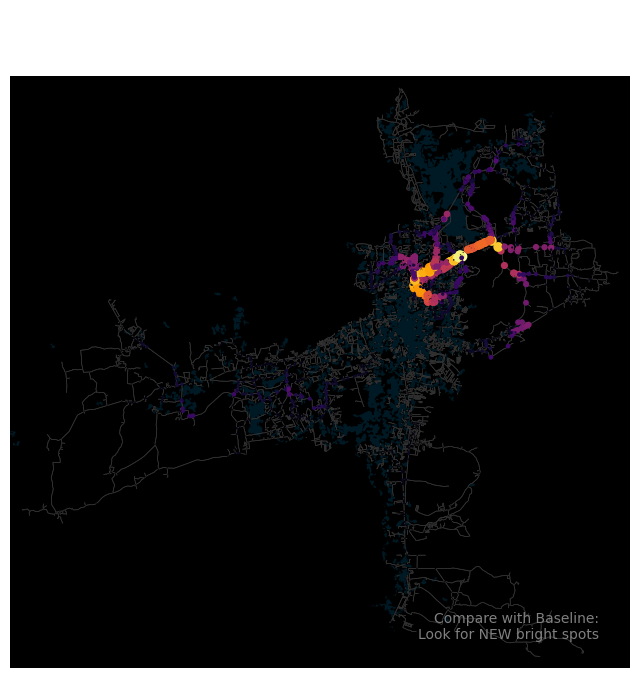

In [7]:
import networkx as nx
import osmnx as ox
import matplotlib.pyplot as plt

# ==========================================
# 1. 重新计算中心性 (Recalculation)
# ==========================================
print("⏳ 正在重新计算灾后路网的中心性 (k=500)...")

# 确保 G_flood 存在
if 'G_flood' not in globals():
    print("❌ G_flood 变量丢失，请重新运行上面的'物理破坏图'代码！")
else:
    # 计算介数中心性 (近似计算)
    bc_flood = nx.betweenness_centrality(ox.get_digraph(G_flood), weight='length', k=500)
    
    # 关键步骤：把计算结果存入图的属性中，名字叫 'bc_flood'
    nx.set_node_attributes(G_flood, bc_flood, 'bc_flood')

    # ==========================================
    # 2. 准备绘图数据 (Cyberpunk Style)
    # ==========================================
    print("🎨 正在绘制灾后热力图...")

    # 动态节点大小：根据重要性放大
    # 使用 .get(node, 0) 防止某些孤立点没有数值
    flood_node_sizes = [bc_flood.get(node, 0) * 1500 for node in G_flood.nodes()]

    # 【关键修改】获取颜色
    # 直接传属性名 'bc_flood'，不要用 attr_name=...
    try:
        nc_flood = ox.plot.get_node_colors_by_attr(G_flood, 'bc_flood', cmap='inferno')
    except Exception as e:
        print(f"⚠️ 颜色获取失败: {e}")
        # 如果万一还报错，给个保底颜色（红色）
        nc_flood = 'red'

    # ==========================================
    # 3. 绘图
    # ==========================================
    fig, ax = ox.plot_graph(
        G_flood,
        node_color=nc_flood,
        node_size=flood_node_sizes, # 动态大小
        node_zorder=2,
        edge_color='#333333',       # 深灰背景
        edge_linewidth=0.5,
        bgcolor='black',
        show=False,
        close=False
    )

    # 再次把洪水画上去，作为背景参考，方便对比
    # 确保 flood_clean 也是存在的
    if 'flood_clean' in globals():
        # 统一坐标系到路网 (UTM)
        flood_viz = flood_clean.to_crs(G_flood.graph['crs'])
        flood_viz.plot(ax=ax, color='#00B0FF', alpha=0.15, zorder=0)

    ax.set_title("Post-Flood Topology: Stress Shift\n(Where must the traffic go now?)", 
                 color='white', fontsize=15, pad=20)

    ax.text(0.95, 0.05, "Compare with Baseline:\nLook for NEW bright spots", 
            transform=ax.transAxes, ha='right', color='gray', fontsize=10)

    plt.show()

📊 正在生成左右对比分析图...


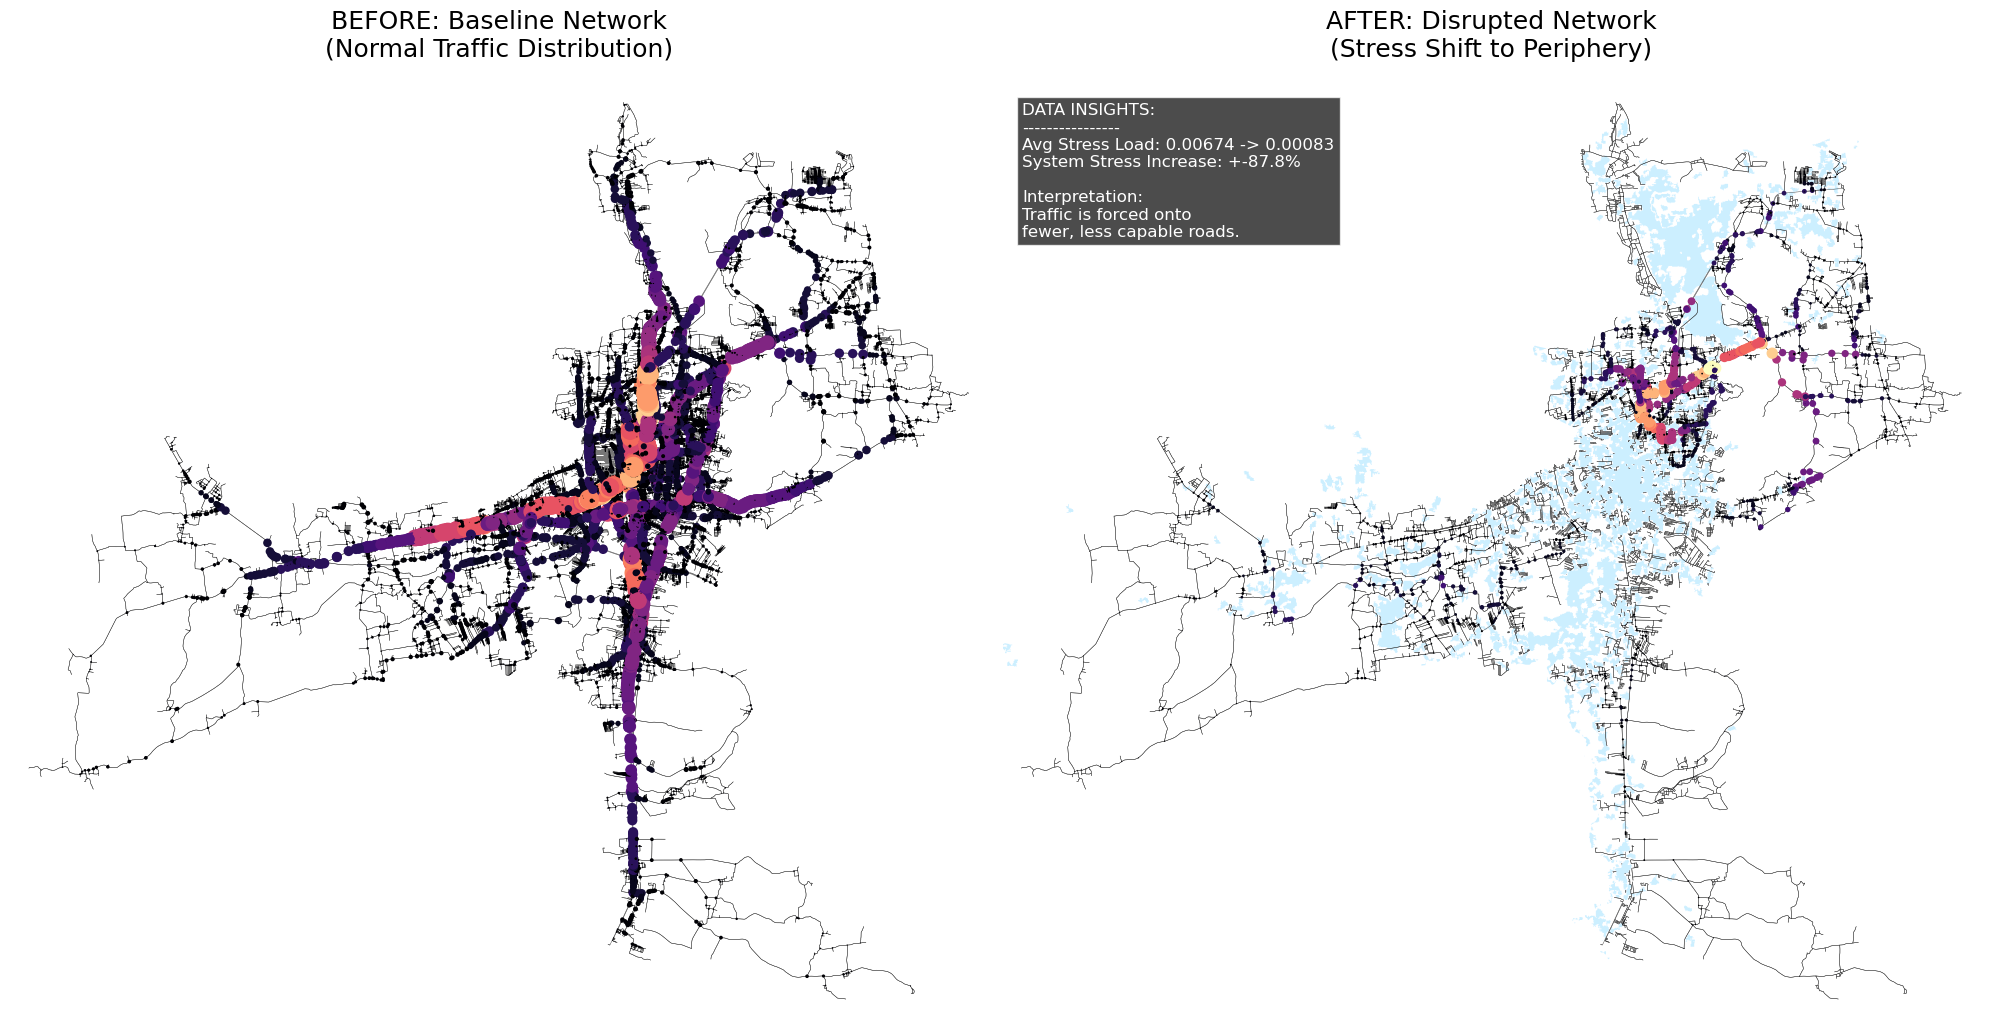

In [11]:
import matplotlib.pyplot as plt
import osmnx as ox
import networkx as nx
import numpy as np

# ==========================================
# 1. 配置与数据准备
# ==========================================
print("📊 正在生成左右对比分析图...")

# 🎨 颜色配置 (在这里改颜色！)
# 推荐: 'inferno' (黑红黄), 'magma' (黑紫亮黄), 'Spectral' (红黄蓝)
# 想要对比明显，推荐 'magma' 或 'inferno'
CMAP_STYLE = 'magma' 

# 确保数据都在
if 'G_proj' not in globals() or 'bc' not in globals() or \
   'G_flood' not in globals() or 'bc_flood' not in globals():
    print("❌ 数据缺失，请先运行前面的计算代码！")
else:
    # --- 关键步骤：统一量纲 (Normalization) ---
    # 为了让两张图能对比，必须用同一个最大值
    max_val_baseline = max(bc.values())
    max_val_flood = max(bc_flood.values())
    global_max = max(max_val_baseline, max_val_flood)
    
    # --- 计算统计数据 ---
    avg_bc_base = np.mean(list(bc.values()))
    avg_bc_flood = np.mean(list(bc_flood.values()))
    change_pct = ((avg_bc_flood - avg_bc_base) / avg_bc_base) * 100

    # ==========================================
    # 2. 绘图 (左右布局)
    # ==========================================
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10), facecolor='white')

    # -----------------------------
    # 左图: Baseline (平时)
    # -----------------------------
    # 节点颜色 & 大小
    nc_base = ox.plot.get_node_colors_by_attr(G_proj, 'bc', cmap=CMAP_STYLE, num_bins=20)
    # 动态大小: 乘以 2000 让点大一点
    ns_base = [bc.get(node, 0) * 2000 for node in G_proj.nodes()]

    ox.plot_graph(G_proj, ax=ax1, node_color=nc_base, node_size=ns_base,
                  edge_color='#333333', edge_linewidth=0.3, bgcolor='black',
                  show=False, close=False)
    
    ax1.set_title("BEFORE: Baseline Network\n(Normal Traffic Distribution)", 
                  color='black', fontsize=18, pad=20)

    # -----------------------------
    # 右图: Post-Flood (灾后)
    # -----------------------------
    # 节点颜色 & 大小
    # 注意：这里我们用 global_max 也可以，或者让它自动适应展示相对重要性
    # 这里用自动适应，展示"新的中心在哪里"
    nc_flood = ox.plot.get_node_colors_by_attr(G_flood, 'bc_flood', cmap=CMAP_STYLE, num_bins=20)
    ns_flood = [bc_flood.get(node, 0) * 2000 for node in G_flood.nodes()]

    ox.plot_graph(G_flood, ax=ax2, node_color=nc_flood, node_size=ns_flood,
                  edge_color='#333333', edge_linewidth=0.3, bgcolor='black',
                  show=False, close=False)
    
    # 把洪水画在右图背景里
    if 'flood_clean' in globals():
        flood_viz = flood_clean.to_crs(G_flood.graph['crs'])
        flood_viz.plot(ax=ax2, color='#00B0FF', alpha=0.2, zorder=0)

    ax2.set_title("AFTER: Disrupted Network\n(Stress Shift to Periphery)", 
                  color='black', fontsize=18, pad=20)

    # ==========================================
    # 3. 添加数据统计面板 (Data Overlay)
    # ==========================================
    stats_text = (
        f"DATA INSIGHTS:\n"
        f"----------------\n"
        f"Avg Stress Load: {avg_bc_base:.5f} -> {avg_bc_flood:.5f}\n"
        f"System Stress Increase: +{change_pct:.1f}%\n\n"
        f"Interpretation:\n"
        f"Traffic is forced onto\n"
        f"fewer, less capable roads."
    )
    
    # 在两图中间或者底部放文字
    # 这里放在右图的左上角
    ax2.text(0.02, 0.98, stats_text, transform=ax2.transAxes, 
             fontsize=12, color='white', va='top', ha='left',
             bbox=dict(facecolor='black', edgecolor='white', alpha=0.7))

    plt.tight_layout()
    plt.show()